In [2]:
import seaborn as sns
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.ticker as mticker
from sklearn.metrics import mean_absolute_error, mean_squared_error
from prophet import Prophet
from statsmodels.tsa.arima.model import ARIMA
import statsmodels.api as sm

In [3]:
#regionalAttendance =  (finalData.groupby(['MonthYear','Region'], as_index=False)['Total Attendances'].sum())

#finalData = finalData[finalData['Region'] == 'London Region']
#finalData = finalData[finalData['Region'] == 'Midlands England']
#finalData = finalData[finalData['Region'] == 'North-West England'] #19%, 16%
#finalData = finalData[finalData['Region'] == 'South-East England'] #7.30 - 5
#finalData = finalData[finalData['Region'] == 'Midlands England'] # 3.18 - 4.50
#finalData = finalData[finalData['Region'] == 'South-East England'] # 3.18 -


In [4]:
finalDataTwo = pd.read_csv(r"C:\Users\DELL\Desktop\Uni25-26\Project\work\DATA\processedData\finalDataTwo.csv")
finalDataTwo['MonthYear'] = pd.to_datetime(finalDataTwo['MonthYear'])
                           

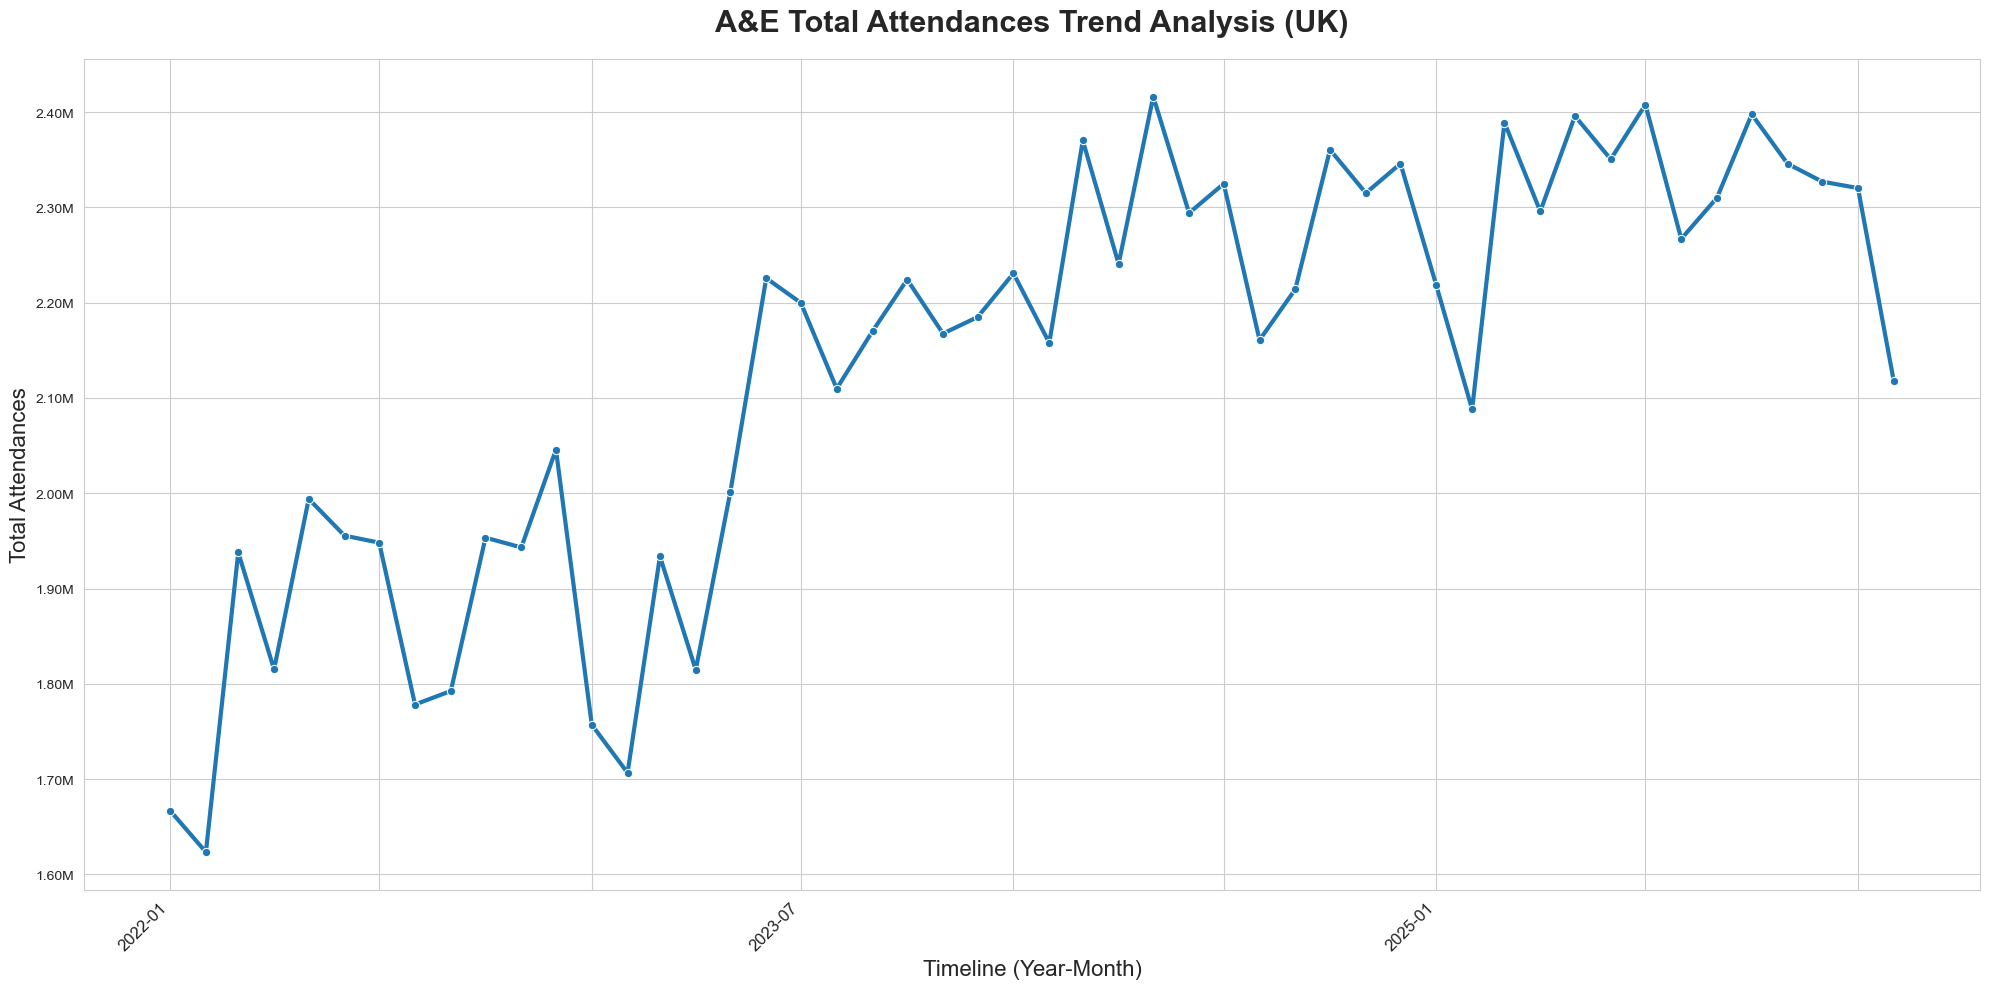

In [5]:


# 1. Load with strict date parsing
finalData = pd.read_csv(r"C:\Users\DELL\Desktop\Uni25-26\Project\work\DATA\processedData\finalData.csv")
#finalData = finalData[finalData['Region'] == 'South-East England']
# Use dayfirst=True to ensure 01-06 is June, not January
date='2022-01-01'
finalData['MonthYear'] = pd.to_datetime(finalData['MonthYear'])
finalData = finalData[finalData["MonthYear"] >=date]

# 2. Aggregate to remove regional stacking
yearlyDataUk = finalData.groupby(['MonthYear'], as_index=False)['Total Attendances'].sum()
yearlyDataUk = yearlyDataUk.rename(columns={'MonthYear': 'ds', 'Total Attendances': 'y'}).sort_values('ds')

# 3. Create the clean YYYY-MM labels
yearlyDataUk['year_month'] = yearlyDataUk['ds'].dt.strftime('%Y-%m')

# 4. Final Professional Plot
plt.figure(figsize=(20, 10), dpi=100)
sns.set_style("whitegrid") # Adds a clean background

# Plotting with the string labels to force a discrete X-axis
ax = sns.lineplot(x='ds', y='y', data=yearlyDataUk, marker='o', linewidth=3, color='#1f77b4')

# Title and Labels
plt.title("A&E Total Attendances Trend Analysis (UK)", fontsize=22, pad=20, fontweight='bold')
plt.xlabel("Timeline (Year-Month)", fontsize=16)
plt.ylabel("Total Attendances", fontsize=16)

# Formatting the Y-axis to Millions
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.2f}M'))

# Rotating labels and cleaning up X-axis density
plt.xticks(rotation=45, ha='right', fontsize=12)

# Only show every 3rd label so they don't overlap
for n, label in enumerate(ax.xaxis.get_ticklabels()):
    if n % 3 != 0:
        label.set_visible(False)

plt.tight_layout()
plt.show()

In [6]:
yearlyDataUk.head()

,ds,y,year_month
0,2022-01-01,1667031.0,2022-01
1,2022-02-01,1623462.0,2022-02
2,2022-03-01,1937866.0,2022-03
3,2022-04-01,1815200.0,2022-04
4,2022-05-01,1994077.0,2022-05


# 6 months prediction with Prophet 

In [8]:
data = yearlyDataUk.copy()

# Train and Test data frames
test = data.iloc[-6:].sort_values(by='ds', ascending=True).reset_index(drop=True)
train = data.iloc[:-6].sort_values(by='ds', ascending=True).reset_index(drop=True)

In [9]:
model6Months = Prophet(interval_width=0.95,
                      changepoint_prior_scale=0.05,
                      seasonality_prior_scale=10.0,
                      seasonality_mode='additive'
                      )
model6Months.add_seasonality(name='monthly', period=30.5, fourier_order=5)
#model6Months.add_regressor('is_strike')
           
model6Months.fit(train)
future_dates6Months = model6Months.make_future_dataframe(periods=len(test), freq='MS')
#future_dates6Months = custom_event(future_dates6Months)
forecast = model6Months.predict(future_dates6Months)

10:40:14 - cmdstanpy - INFO - Chain [1] start processing
10:40:15 - cmdstanpy - INFO - Chain [1] done processing


In [10]:
#only forecasts for the test period (last 6 months)
cutoff = train['ds'].max()
forecastplt6months = forecast[forecast['ds'] > cutoff][['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

forecastplt6months['yhat'] = forecastplt6months['yhat'].round(0).astype(int)
forecastplt6months = forecastplt6months.reset_index(drop=True)[['ds','yhat']]

In [11]:
train.tail()

,ds,y,year_month
39,2025-04-01,2295820.0,2025-04
40,2025-05-01,2395886.0,2025-05
41,2025-06-01,2350478.0,2025-06
42,2025-07-01,2407884.0,2025-07
43,2025-08-01,2266937.0,2025-08


In [12]:
forecastplt6months

,ds,yhat
0,2025-09-01,2315217
1,2025-10-01,2439551
2,2025-11-01,2408620
3,2025-12-01,2435974
4,2026-01-01,2303833
5,2026-02-01,2226770


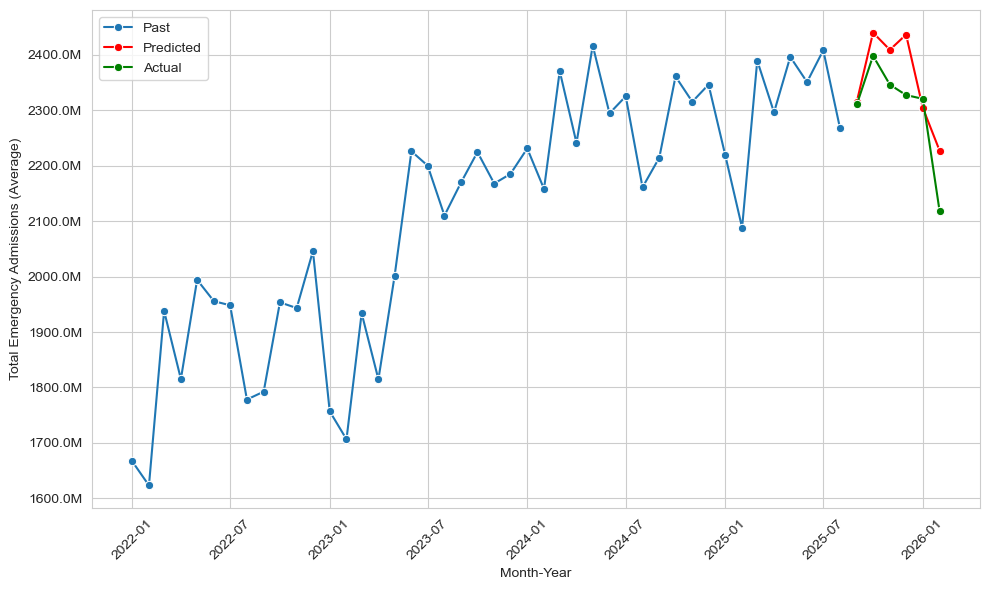

In [13]:
plt.figure(figsize=(10,6))
sns.lineplot(x='ds', y='y', data=train, label='Past', marker='o')
sns.lineplot(x='ds', y='yhat', data=forecastplt6months, label='Predicted', marker='o', color='red')
sns.lineplot(x='ds', y='y', data=test, label='Actual', marker='o', color='green')

#plt.title('Last 30% Actual vs Predicted Emergency Admissions Over Time\nNHS England London (Test Set)')
plt.xlabel('Month-Year')
plt.ylabel('Total Emergency Admissions (Average)')
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1000:.1f}M'))
plt.legend()
plt.tight_layout()
plt
plt.show()

In [14]:
eval_df = test.merge(forecastplt6months[['ds', 'yhat']], on='ds', how='inner')
eval_df = eval_df.rename(columns={'y': 'y_true', 'yhat': 'y_pred'})

y_true = eval_df['y_true'].values
y_pred = eval_df['y_pred'].values

In [15]:
eval_df

,ds,y_true,year_month,y_pred
0,2025-09-01,2310222.0,2025-09,2315217
1,2025-10-01,2397701.0,2025-10,2439551
2,2025-11-01,2345860.0,2025-11,2408620
3,2025-12-01,2327015.0,2025-12,2435974
4,2026-01-01,2320266.0,2026-01,2303833
5,2026-02-01,2117450.0,2026-02,2226770


In [16]:
# MAE
mae = mean_absolute_error(y_true, y_pred)

# MSE
mse = mean_squared_error(y_true, y_pred)

# RMSE
rmse = np.sqrt(mse)

# MAPE
non_zero = y_true != 0
mape = np.mean(np.abs((y_true[non_zero] - y_pred[non_zero]) / y_true[non_zero])) * 100

print(f"Date horizon {date} - 2025 max ")
print(f"Prophet 6-MONTH MAE  : {mae:,.0f}")
print(f"Prophet 6-MONTH MSE  : {mse:,.0f}")
print(f"Prophet 6-MONTH RMSE : {rmse:,.0f}")
print(f"Prophet 6-MONTH MAPE : {mape:.2f}%")


Date horizon 2022-01-01 - 2025 max 
Prophet 6-MONTH MAE  : 57,386
Prophet 6-MONTH MSE  : 4,968,026,616
Prophet 6-MONTH RMSE : 70,484
Prophet 6-MONTH MAPE : 2.53%


# 3 months prediction with Prophet 

In [18]:
testThreeProphet = data.iloc[-3:].sort_values(by='ds', ascending=True).reset_index(drop=True)
trainThreeProphet = data.iloc[:-3].sort_values(by='ds', ascending=True).reset_index(drop=True)

In [19]:
trainThreeProphet.tail()

,ds,y,year_month
42,2025-07-01,2407884.0,2025-07
43,2025-08-01,2266937.0,2025-08
44,2025-09-01,2310222.0,2025-09
45,2025-10-01,2397701.0,2025-10
46,2025-11-01,2345860.0,2025-11


In [20]:
model3Months = Prophet(interval_width=0.95)
model3Months.fit(trainThreeProphet)
future_dates3Months = model3Months.make_future_dataframe(periods=len(testThreeProphet), freq='MS')
forecast = model3Months.predict(future_dates3Months)

10:40:17 - cmdstanpy - INFO - Chain [1] start processing
10:40:19 - cmdstanpy - INFO - Chain [1] done processing


In [21]:
cutoff = trainThreeProphet['ds'].max()
forecastplt3months = forecast[forecast['ds'] > cutoff][['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

forecastplt3months['yhat'] = forecastplt3months['yhat'].round(0).astype(int)
forecastplt3months = forecastplt3months.reset_index(drop=True)[['ds','yhat']]

In [22]:
trainThreeProphet.tail()

,ds,y,year_month
42,2025-07-01,2407884.0,2025-07
43,2025-08-01,2266937.0,2025-08
44,2025-09-01,2310222.0,2025-09
45,2025-10-01,2397701.0,2025-10
46,2025-11-01,2345860.0,2025-11


In [23]:
forecastplt3months

,ds,yhat
0,2025-12-01,2418197
1,2026-01-01,2244104
2,2026-02-01,2152489


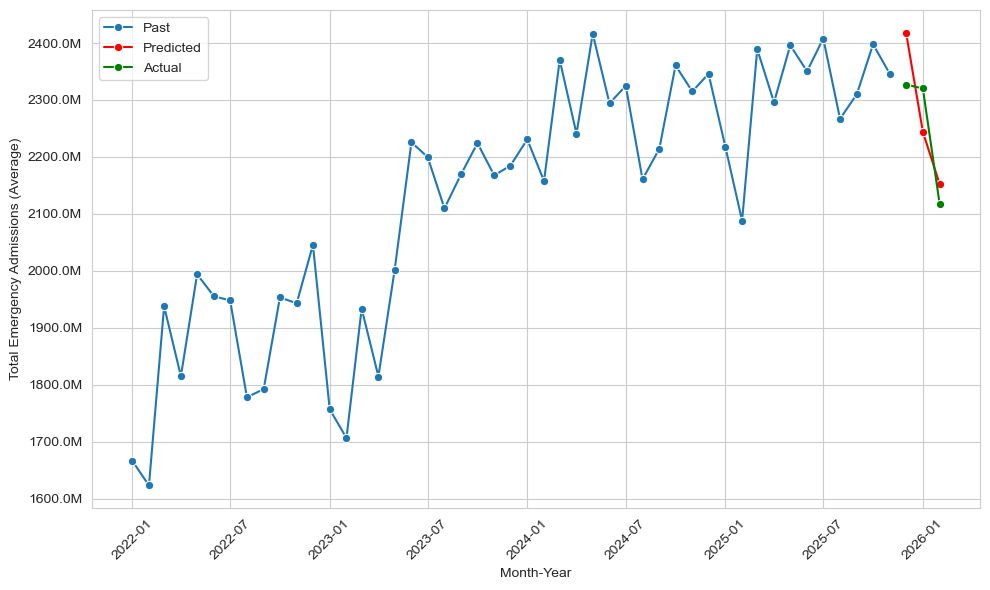

In [24]:
plt.figure(figsize=(10,6))
sns.lineplot(x='ds', y='y', data=trainThreeProphet, label='Past', marker='o')
sns.lineplot(x='ds', y='yhat', data=forecastplt3months, label='Predicted', marker='o', color='red')
sns.lineplot(x='ds', y='y', data=testThreeProphet, label='Actual', marker='o', color='green')

#plt.title('Last 30% Actual vs Predicted Emergency Admissions Over Time\nNHS England London (Test Set)')
plt.xlabel('Month-Year')
plt.ylabel('Total Emergency Admissions (Average)')
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1000:.1f}M'))
plt.legend()
plt.tight_layout()
plt.show()

In [25]:
eval_df = test.merge(forecastplt3months[['ds', 'yhat']], on='ds', how='inner')
eval_df = eval_df.rename(columns={'y': 'y_true', 'yhat': 'y_pred'})

y_true = eval_df['y_true'].values
y_pred = eval_df['y_pred'].values

In [26]:
eval_df

,ds,y_true,year_month,y_pred
0,2025-12-01,2327015.0,2025-12,2418197
1,2026-01-01,2320266.0,2026-01,2244104
2,2026-02-01,2117450.0,2026-02,2152489


In [27]:


# MAE
mae = mean_absolute_error(y_true, y_pred)

# MSE
mse = mean_squared_error(y_true, y_pred)

# RMSE
rmse = np.sqrt(mse)

# MAPE
non_zero = y_true != 0
mape = np.mean(np.abs((y_true[non_zero] - y_pred[non_zero]) / y_true[non_zero])) * 100

print(f"Date horizon {date} - 2025 max ")
print(f"Prophet 3-MONTH MAE  : {mae:,.0f}")
print(f"Prophet 3-MONTH MSE  : {mse:,.0f}")
print(f"Prophet 3-MONTH RMSE : {rmse:,.0f}")
print(f"Prophet 3-MONTH MAPE : {mape:.2f}%")

Date horizon 2022-01-01 - 2025 max 
Prophet 3-MONTH MAE  : 67,461
Prophet 3-MONTH MSE  : 5,114,179,630
Prophet 3-MONTH RMSE : 71,513
Prophet 3-MONTH MAPE : 2.95%


# Arima model to predict next 6 months of attendance nation wide

In [29]:
trainarima = data.iloc[:-6].sort_values('ds').reset_index(drop=True)
testarima  = data.iloc[-6:].sort_values('ds').reset_index(drop=True)


In [30]:
trainseries = trainarima.set_index('ds')['y']
trainseries.index = pd.DatetimeIndex(trainseries.index).to_period('M') 

In [31]:
modelarima = sm.tsa.ARIMA(trainseries, order=(1,1,1))
modelarimafit = modelarima.fit()
forecastvalues = modelarimafit.forecast(steps=len(testarima))
forecastarimadf = pd.DataFrame({'ds': forecastvalues.index,'yhat': forecastvalues.values})
forecastarimadf['ds'] = forecastarimadf['ds'].dt.to_timestamp()
forecastarimadf['yhat'] = forecastarimadf['yhat'].round(0).astype(int)

In [32]:
forecastplt6monthsarima =(forecastarimadf.reset_index(drop=True)[['ds', 'yhat']])

In [33]:
forecastplt6monthsarima

,ds,yhat
0,2025-09-01,2296102
1,2025-10-01,2274167
2,2025-11-01,2290665
3,2025-12-01,2278257
4,2026-01-01,2287589
5,2026-02-01,2280570


In [34]:
forecastplt6months

,ds,yhat
0,2025-09-01,2315217
1,2025-10-01,2439551
2,2025-11-01,2408620
3,2025-12-01,2435974
4,2026-01-01,2303833
5,2026-02-01,2226770


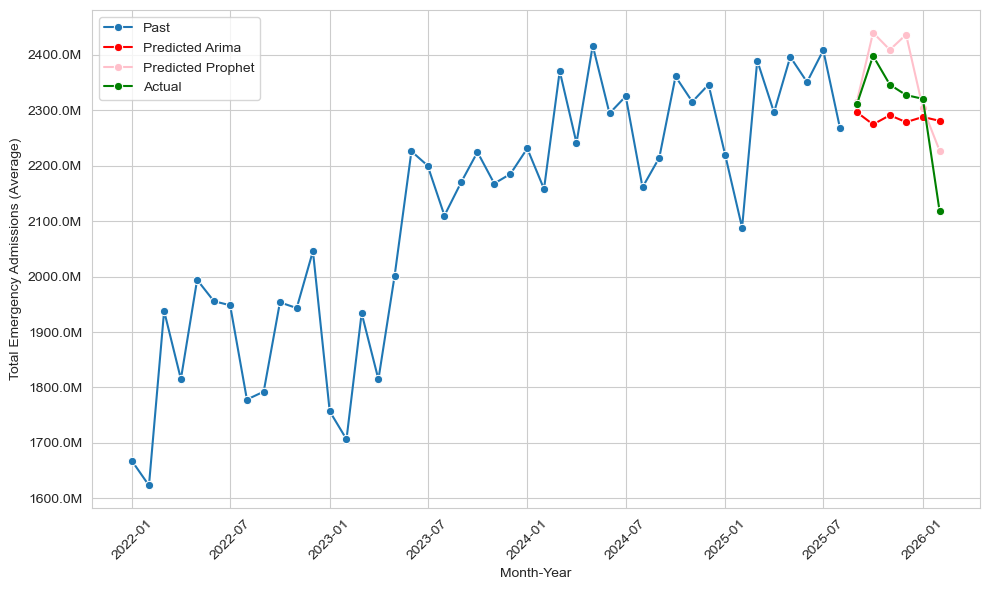

In [35]:
plt.figure(figsize=(10,6))
sns.lineplot(x='ds', y='y', data=trainarima, label='Past', marker='o')
sns.lineplot(x='ds', y='yhat', data=forecastplt6monthsarima, label='Predicted Arima', marker='o', color='red')
sns.lineplot(x='ds', y='yhat', data=forecastplt6months, label='Predicted Prophet', marker='o', color='pink')
sns.lineplot(x='ds', y='y', data=testarima, label='Actual', marker='o', color='green')

#plt.title('Last 30% Actual vs Predicted Emergency Admissions Over Time\nNHS England London (Test Set)')
plt.xlabel('Month-Year')
plt.ylabel('Total Emergency Admissions (Average)')
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1000:.1f}M'))
plt.legend()
plt.tight_layout()
plt.show()

In [36]:
pred_arima = forecastplt6monthsarima.rename(columns={'yhat': 'y_pred'})
true_arima = testarima.rename(columns={'y': 'y_true'})

eval_df_arima = true_arima.merge(pred_arima, on='ds', how='inner')



# Metrics
y_true = eval_df_arima['y_true'].values
y_pred = eval_df_arima['y_pred'].values

mae_arima = mean_absolute_error(y_true, y_pred)
mse_arima = mean_squared_error(y_true, y_pred)
rmse_arima = np.sqrt(mse_arima)

non_zero_mask = y_true != 0
mape_arima = np.mean(np.abs((y_true[non_zero_mask] - y_pred[non_zero_mask]) / y_true[non_zero_mask])) * 100

print(f"Date horizon {date} - 2025 max ")
print(f"ARIMA 6-MONTH MAE  : {mae_arima:,.0f}")
print(f"ARIMA 6-MONTH MSE  : {mse_arima:,.0f}")
print(f"ARIMA 6-MONTH RMSE : {rmse_arima:,.0f}")
print(f"ARIMA 6-MONTH MAPE : {mape_arima:.2f}%")


Date horizon 2022-01-01 - 2025 max 
ARIMA 6-MONTH MAE  : 72,901
ARIMA 6-MONTH MSE  : 8,093,295,812
ARIMA 6-MONTH RMSE : 89,963
ARIMA 6-MONTH MAPE : 3.22%


# Arima model to predict next 3 months of attendance

In [38]:
trainarima = data.iloc[:-3].sort_values('ds').reset_index(drop=True)
testarima  = data.iloc[-3:].sort_values('ds').reset_index(drop=True)

In [39]:
trainseries = trainarima.set_index('ds')['y']
trainseries.index = pd.DatetimeIndex(trainseries.index).to_period('M') 

In [40]:
modelarima = sm.tsa.ARIMA(trainseries, order=(1,1,1))
modelarimafit = modelarima.fit()
forecastvalues = modelarimafit.forecast(steps=len(testarima))
forecastarimadf = pd.DataFrame({'ds': forecastvalues.index,'yhat': forecastvalues.values})
forecastarimadf['ds'] = forecastarimadf['ds'].dt.to_timestamp()
forecastarimadf['yhat'] = forecastarimadf['yhat'].round(0).astype(int)

In [41]:
forecastplt3monthsarima =(forecastarimadf.reset_index(drop=True)[['ds', 'yhat']])

In [42]:
forecastplt3monthsarima

,ds,yhat
0,2025-12-01,2348245
1,2026-01-01,2346485
2,2026-02-01,2347784


In [43]:
forecastplt3months

,ds,yhat
0,2025-12-01,2418197
1,2026-01-01,2244104
2,2026-02-01,2152489


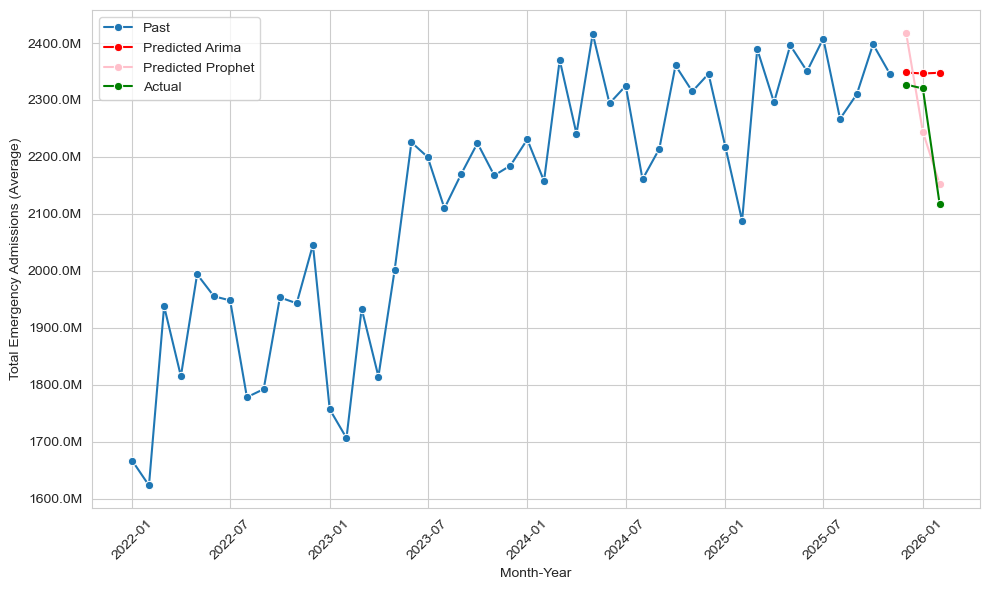

In [44]:
plt.figure(figsize=(10,6))
sns.lineplot(x='ds', y='y', data=trainarima, label='Past', marker='o')
sns.lineplot(x='ds', y='yhat', data=forecastplt3monthsarima, label='Predicted Arima', marker='o', color='red')
sns.lineplot(x='ds', y='yhat', data=forecastplt3months, label='Predicted Prophet', marker='o', color='pink')
sns.lineplot(x='ds', y='y', data=testarima, label='Actual', marker='o', color='green')

#plt.title('Last 30% Actual vs Predicted Emergency Admissions Over Time\nNHS England London (Test Set)')
plt.xlabel('Month-Year')
plt.ylabel('Total Emergency Admissions (Average)')
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1000:.1f}M'))
plt.legend()
plt.tight_layout()
plt.show()

In [45]:
pred_arima = forecastplt3monthsarima.rename(columns={'yhat': 'y_pred'})
true_arima = testarima.rename(columns={'y': 'y_true'})

eval_df_arima = true_arima.merge(pred_arima, on='ds', how='inner')



# Metrics
y_true = eval_df_arima['y_true'].values
y_pred = eval_df_arima['y_pred'].values

mae_arima = mean_absolute_error(y_true, y_pred)
mse_arima = mean_squared_error(y_true, y_pred)
rmse_arima = np.sqrt(mse_arima)

non_zero_mask = y_true != 0
mape_arima = np.mean(np.abs((y_true[non_zero_mask] - y_pred[non_zero_mask]) / y_true[non_zero_mask])) * 100


print(f"Date horizon {date} - 2025 max ")
print(f"ARIMA 3-MONTH MAE  : {mae_arima:,.0f}")
print(f"ARIMA 3-MONTH MSE  : {mse_arima:,.0f}")
print(f"ARIMA 3-MONTH RMSE : {rmse_arima:,.0f}")
print(f"ARIMA 3-MONTH MAPE : {mape_arima:.2f}%")


Date horizon 2022-01-01 - 2025 max 
ARIMA 3-MONTH MAE  : 92,594
ARIMA 3-MONTH MSE  : 18,063,966,806
ARIMA 3-MONTH RMSE : 134,402
ARIMA 3-MONTH MAPE : 4.31%


# 6 months prediction with SARIMA 

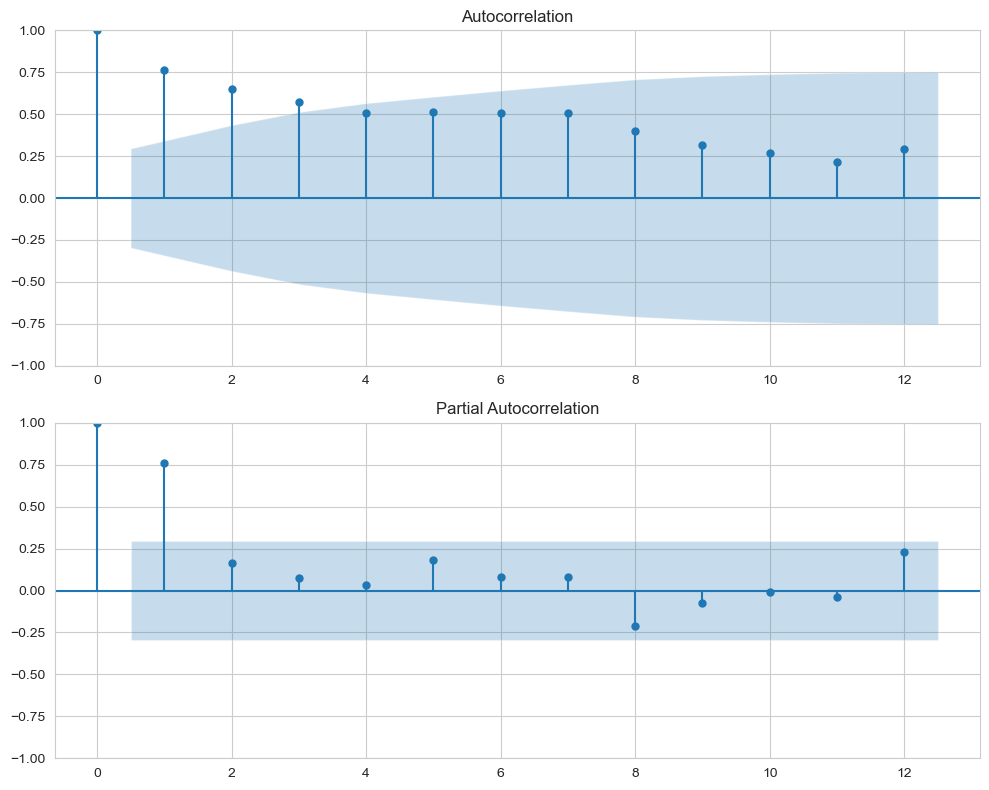

In [47]:
import statsmodels.api as sm
import matplotlib.pyplot as plt


trainSarima = data.iloc[:-6].sort_values('ds').reset_index(drop=True)
testSarima  = data.iloc[-6:].sort_values('ds').reset_index(drop=True)

trainseries = trainSarima.set_index('ds')['y']
trainseries.index = pd.DatetimeIndex(trainseries.index).to_period('M') 

# We look at the 'y' column (Attendances/Admissions)
fig, ax = plt.subplots(2, 1, figsize=(10, 8))

# Reduce lags to 12 or 15 to stay within the 50% sample size limit
# 12 is perfect because it shows exactly one full seasonal cycle for NHS data
lags_to_show = 12 

# ACF helps identify 'q'
sm.graphics.tsa.plot_acf(trainseries, lags=lags_to_show, ax=ax[0]) 

# PACF helps identify 'p'
sm.graphics.tsa.plot_pacf(trainseries, lags=lags_to_show, ax=ax[1]) 

plt.tight_layout()
plt.show()

C:\Users\DELL\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


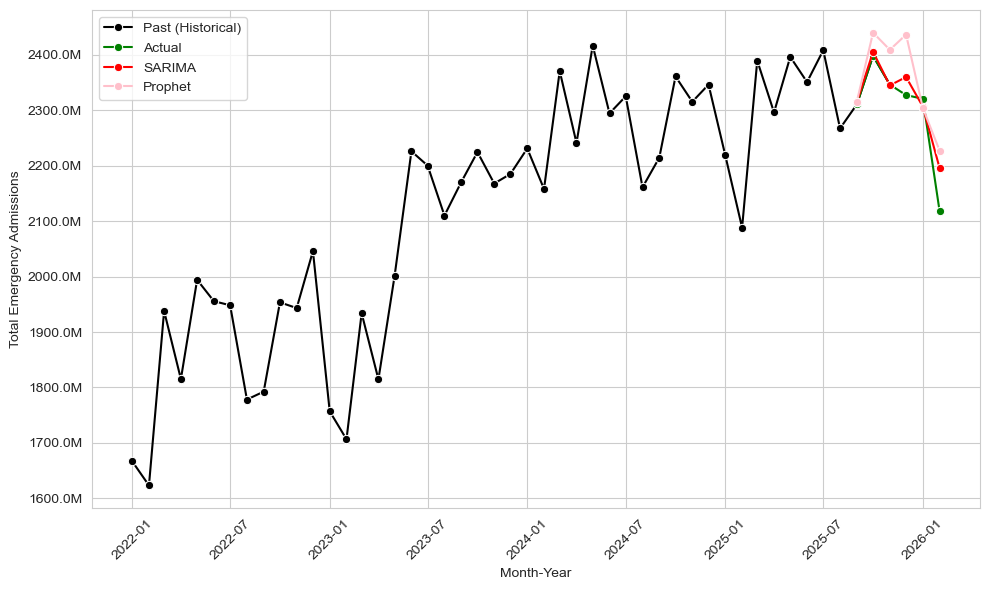

In [48]:
import statsmodels.api as sm



# 2. Prepare the time series for SARIMA
trainseries = trainSarima.set_index('ds')['y'].asfreq('MS')

# 3. Fit the SARIMA Model
# (1,1,1)x(1,1,1,12) captures the yearly NHS seasonal cycle
model_sarima = sm.tsa.statespace.SARIMAX(trainseries, 
                                        order=(1, 2, 1), 
                                        seasonal_order=(1, 1, 1, 12),
                                        enforce_stationarity=False,
                                        enforce_invertibility=False)
model_sarima_fit = model_sarima.fit(disp=False)

# 4. Forecast for the EXACT length of the test set
# red line starts exactly where the pink (Prophet) line starts
forecast_res = model_sarima_fit.get_forecast(steps=len(testSarima))
forecast_sarima_df = pd.DataFrame({
    'ds': testSarima['ds'].values, 
    'yhat': forecast_res.predicted_mean.values
})

forecast_sarima_df['yhat'] = forecast_sarima_df['yhat'].round(0).astype(int)

# 5. Visualization
plt.figure(figsize=(10,6))
sns.lineplot(x='ds', y='y', data=trainarima, label='Past (Historical)', marker='o', color='black')
sns.lineplot(x='ds', y='y', data=testSarima, label='Actual', marker='o', color='green')

# Both of these will now start at the same X-coordinate (the first date in testarima)
sns.lineplot(x='ds', y='yhat', data=forecast_sarima_df, label='SARIMA', marker='o', color='red')
sns.lineplot(x='ds', y='yhat', data=forecastplt6months, label='Prophet', marker='o', color='pink')

plt.xlabel('Month-Year')
plt.ylabel('Total Emergency Admissions')
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1000:.1f}M'))
plt.legend()
plt.tight_layout()
plt.show()

In [49]:
pred_arima = forecast_sarima_df.rename(columns={'yhat': 'y_pred'})
true_arima = testarima.rename(columns={'y': 'y_true'})

eval_df_arima = true_arima.merge(pred_arima, on='ds', how='inner')



# Metrics
y_true = eval_df_arima['y_true'].values
y_pred = eval_df_arima['y_pred'].values

mae_arima = mean_absolute_error(y_true, y_pred)
mse_arima = mean_squared_error(y_true, y_pred)
rmse_arima = np.sqrt(mse_arima)

non_zero_mask = y_true != 0
mape_arima = np.mean(np.abs((y_true[non_zero_mask] - y_pred[non_zero_mask]) / y_true[non_zero_mask])) * 100

print(f"Date horizon {date} - 2025 max ")
print(f"SARIMA 6-MONTH MAE  : {mae_arima:,.0f}")
print(f"SARIMA 6-MONTH MSE  : {mse_arima:,.0f}")
print(f"SARIMA 6-MONTH RMSE : {rmse_arima:,.0f}")
print(f"SARIMA 6-MONTH MAPE : {mape_arima:.2f}%")

Date horizon 2022-01-01 - 2025 max 
SARIMA 6-MONTH MAE  : 41,465
SARIMA 6-MONTH MSE  : 2,437,304,355
SARIMA 6-MONTH RMSE : 49,369
SARIMA 6-MONTH MAPE : 1.89%


# 3 months prediction with SARIMA 

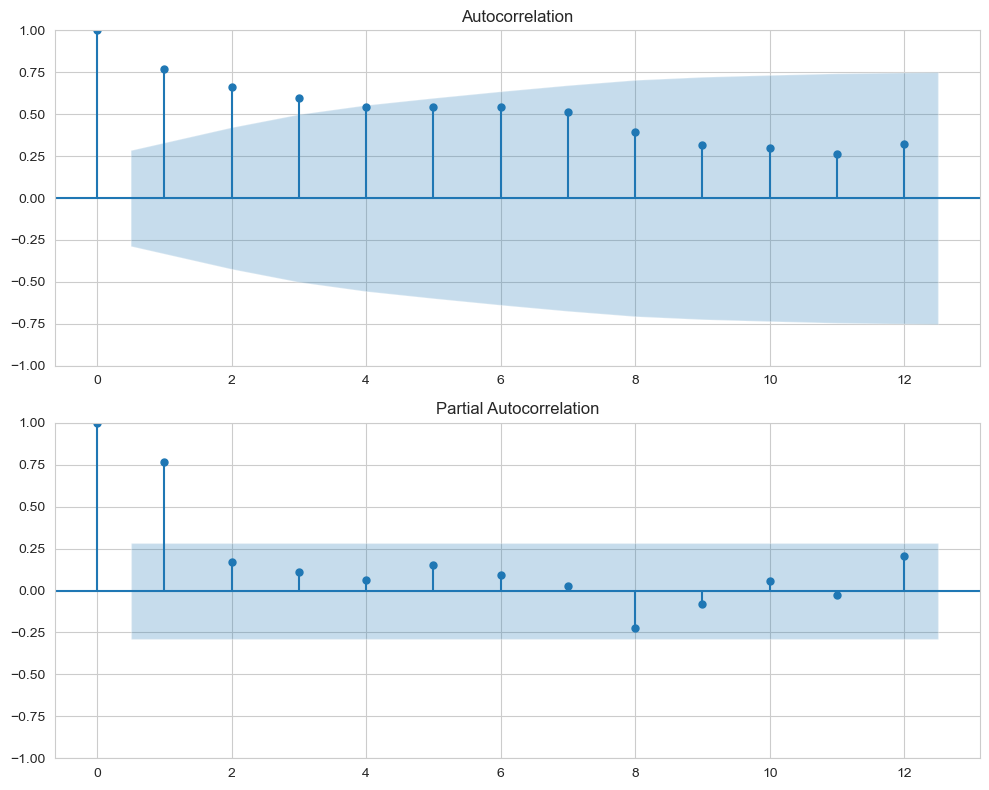

In [51]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

trainSarima = data.iloc[:-3].sort_values('ds').reset_index(drop=True)
testSarima  = data.iloc[-3:].sort_values('ds').reset_index(drop=True)

trainseries = trainSarima.set_index('ds')['y']
trainseries.index = pd.DatetimeIndex(trainseries.index).to_period('M') 

# We look at the 'y' column (Attendances/Admissions)
fig, ax = plt.subplots(2, 1, figsize=(10, 8))

# Reduce lags to 12 or 15 to stay within the 50% sample size limit
# 12 is perfect because it shows exactly one full seasonal cycle for NHS data
lags_to_show = 12 

# ACF helps identify 'q'
sm.graphics.tsa.plot_acf(trainseries, lags=lags_to_show, ax=ax[0]) 

# PACF helps identify 'p'
sm.graphics.tsa.plot_pacf(trainseries, lags=lags_to_show, ax=ax[1]) 

plt.tight_layout()
plt.show()

In [52]:
finalDataTwo[['MonthYear','Total Attendances']]
finalDataTwo = finalDataTwo.groupby(['MonthYear'], as_index=False)['Total Attendances'].sum()



In [53]:
finalDataTwo

,MonthYear,Total Attendances
0,2025-12-01,2327015.0
1,2026-01-01,2320266.0
2,2026-02-01,2117450.0


C:\Users\DELL\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


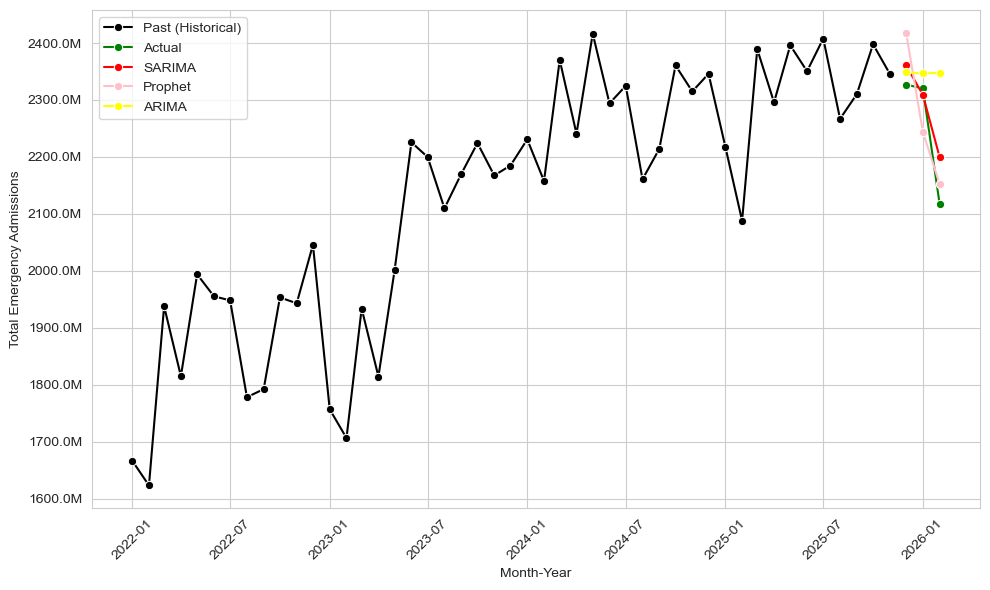

In [54]:
import statsmodels.api as sm

# 1. Ensure the training and test sets are identical for both models
# We take the last 6 months for testing, the rest for training
trainSarima = data.iloc[:-3].sort_values('ds').reset_index(drop=True)
testSarima  = data.iloc[-3:].sort_values('ds').reset_index(drop=True)

# 2. Prepare the time series for SARIMA
trainseries = trainSarima.set_index('ds')['y'].asfreq('MS')

# 3. Fit the SARIMA Model
# (1,1,1)x(1,1,1,12) captures the yearly NHS seasonal cycle
model_sarima = sm.tsa.statespace.SARIMAX(trainseries, 
                                        order=(1, 2, 1), 
                                        seasonal_order=(1, 1, 1, 12),
                                        enforce_stationarity=False,
                                        enforce_invertibility=False)
model_sarima_fit = model_sarima.fit(disp=False)

# 4. Forecast for the EXACT length of the test set
# This ensures the red line starts exactly where the pink (Prophet) line starts
forecast_res = model_sarima_fit.get_forecast(steps=len(testSarima))
forecast_sarima_df = pd.DataFrame({
    'ds': testSarima['ds'].values, # Use the actual dates from testarima to force alignment
    'yhat': forecast_res.predicted_mean.values
})

forecast_sarima_df['yhat'] = forecast_sarima_df['yhat'].round(0).astype(int)

# 5. Visualization
plt.figure(figsize=(10,6))
sns.lineplot(x='ds', y='y', data=trainarima, label='Past (Historical)', marker='o', color='black')
sns.lineplot(x='ds', y='y', data=testarima, label='Actual', marker='o', color='green')

# Both of these will now start at the same X-coordinate (the first date in testarima)
sns.lineplot(x='ds', y='yhat', data=forecast_sarima_df, label='SARIMA', marker='o', color='red')
sns.lineplot(x='ds', y='yhat', data=forecastplt3months, label='Prophet', marker='o', color='pink')
sns.lineplot(x='ds', y='yhat', data=forecastplt3monthsarima, label='ARIMA', marker='o', color='yellow')

#sns.lineplot(x='MonthYear', y='Total Attendances', data=finalDataTwo, label='Actual future', marker='o', color='orange')


finalDataTwo

plt.xlabel('Month-Year')
plt.ylabel('Total Emergency Admissions')
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1000:.1f}M'))
plt.legend()
plt.tight_layout()
plt.show()

In [55]:
pred_arima = forecast_sarima_df.rename(columns={'yhat': 'y_pred'})
true_arima = testarima.rename(columns={'y': 'y_true'})

eval_df_arima = true_arima.merge(pred_arima, on='ds', how='inner')



# Metrics
y_true = eval_df_arima['y_true'].values
y_pred = eval_df_arima['y_pred'].values

mae_arima = mean_absolute_error(y_true, y_pred)
mse_arima = mean_squared_error(y_true, y_pred)
rmse_arima = np.sqrt(mse_arima)

non_zero_mask = y_true != 0
mape_arima = np.mean(np.abs((y_true[non_zero_mask] - y_pred[non_zero_mask]) / y_true[non_zero_mask])) * 100

print(f"Date horizon {date} - 2025 max ")
print(f"SARIMA 3-MONTH MAE  : {mae_arima:,.0f}")
print(f"SARIMA 3-MONTH MSE  : {mse_arima:,.0f}")
print(f"SARIMA 3-MONTH RMSE : {rmse_arima:,.0f}")
print(f"SARIMA 3-MONTH MAPE : {mape_arima:.2f}%")

Date horizon 2022-01-01 - 2025 max 
SARIMA 3-MONTH MAE  : 42,305
SARIMA 3-MONTH MSE  : 2,671,801,705
SARIMA 3-MONTH RMSE : 51,689
SARIMA 3-MONTH MAPE : 1.94%


# Linear regression

## Prophet

In [58]:
months_to_predict=3

In [59]:
model = Prophet(interval_width=0.95,
                      changepoint_prior_scale=0.05,
                      seasonality_prior_scale=10.0,
                      seasonality_mode='additive'
                      )
model.add_seasonality(name='monthly', period=30.5, fourier_order=5)

train_full_set = data.sort_values(by='ds', ascending=True).reset_index(drop=True)
model.fit(train_full_set)
future_dates = model.make_future_dataframe(periods=months_to_predict, freq='MS')
forecast = model.predict(future_dates)

10:40:28 - cmdstanpy - INFO - Chain [1] start processing
10:40:30 - cmdstanpy - INFO - Chain [1] done processing


In [60]:
forecast = model.predict(future_dates)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

,ds,yhat,yhat_lower,yhat_upper
0,2022-01-01,1.627708e+06,1.547571e+06,1.710567e+06
1,2022-02-01,1.635862e+06,1.553519e+06,1.717923e+06
2,2022-03-01,1.905775e+06,1.821294e+06,1.987078e+06
3,2022-04-01,1.760602e+06,1.681372e+06,1.841568e+06
4,2022-05-01,1.953016e+06,1.869990e+06,2.029957e+06
5,2022-06-01,1.976538e+06,1.895002e+06,2.057324e+06
6,2022-07-01,2.003089e+06,1.922190e+06,2.081876e+06
7,2022-08-01,1.837713e+06,1.753521e+06,1.916960e+06
8,2022-09-01,1.820213e+06,1.745413e+06,1.905546e+06
9,2022-10-01,1.977687e+06,1.900772e+06,2.059715e+06


In [61]:
cutoff = yearlyDataUk['ds'].max()   # last date in the data
forecastplt = forecast[forecast['ds'] > cutoff][['ds', 'yhat']]
forecastplt

,ds,yhat
50,2026-03-01,1.809826e+06
51,2026-04-01,2.164274e+06
52,2026-05-01,1.840025e+06


Model Trained. R-squared on full dataset: 0.7773

--- Final 6-Month Forecast (Dec 2025 - May 2026) ---
           ds          yhat  predicted_admissions
50 2026-03-01  1.809826e+06                356488
51 2026-04-01  2.164274e+06                426348
52 2026-05-01  1.840025e+06                362440


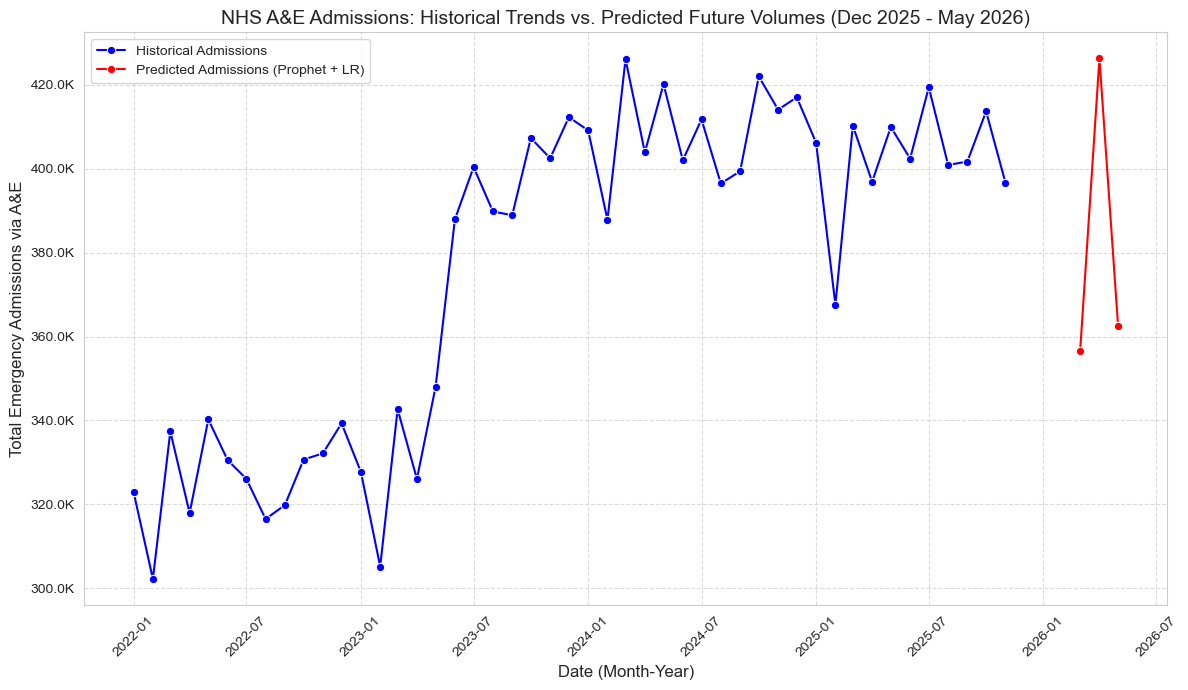

In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
from sklearn.linear_model import LinearRegression

# --- 1. Train the Final Linear Regression Model on ALL Historical Data ---
# We use the entire length of the data to maximize learning for the final future prediction.
X_full = finalData[['Total Attendances']]
y_full = finalData['Total Emergency Admissions via A&E']

LRModel_Final = LinearRegression()
LRModel_Final.fit(X_full, y_full) 

# FIXED: Changed LRModel to LRModel_Final
print(f"Model Trained. R-squared on full dataset: {LRModel_Final.score(X_full, y_full):.4f}")

# --- 2. Predict Future Admissions using Prophet's 6-Month Forecast ---
# We are taking the predicted attendances ('yhat') from your forecastplt data
X_forecast = forecastplt[['yhat']].rename(columns={'yhat': 'Total Attendances'})

# Pass the Prophet forecast into the Linear Regression model
admissions_predictions = LRModel_Final.predict(X_forecast)

# Add predictions to the dataframe and round to nearest whole patient
forecastplt['predicted_admissions'] = admissions_predictions.round(0).astype(int)

print("\n--- Final 6-Month Forecast (Dec 2025 - May 2026) ---")
# Displaying the Date (ds), Predicted Attendances (yhat), and Predicted Admissions
print(forecastplt[['ds', 'yhat', 'predicted_admissions']])

# --- 3. Prepare Data for Plotting ---
# Group historical data to plot the past trend line
admissionplt = finalData[['MonthYear','Total Emergency Admissions via A&E']].copy()
admissionplt = admissionplt.groupby(['MonthYear'], as_index=False)['Total Emergency Admissions via A&E'].sum()

# Since we are predicting Dec 2025 onwards, all historical data up to Nov 2025 is 'Past'
admissionpltPast = admissionplt[admissionplt['MonthYear'] < '2025-12-01']

# --- 4. Generate the Visualization ---
plt.figure(figsize=(12, 7))

# Plot historical past data (Blue line)
sns.lineplot(x='MonthYear', y='Total Emergency Admissions via A&E', data=admissionpltPast, label='Historical Admissions', marker='o', color='blue')

# Plot the predicted future admissions from forecastplt (Red line)
sns.lineplot(x='ds', y='predicted_admissions', data=forecastplt, label='Predicted Admissions (Prophet + LR)', marker='o', color='red')

# Format the chart
plt.title('NHS A&E Admissions: Historical Trends vs. Predicted Future Volumes (Dec 2025 - May 2026)', fontsize=14)
plt.xlabel('Date (Month-Year)', fontsize=12)
plt.ylabel('Total Emergency Admissions via A&E', fontsize=12)
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1000:.1f}K'))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# The weighted model

--- Training Prophet Model ---


10:40:32 - cmdstanpy - INFO - Chain [1] start processing
10:40:33 - cmdstanpy - INFO - Chain [1] done processing


--- Training SARIMA Model ---
--- Training Stacking Ensemble (Meta-Learner) ---
Meta-Learner Weights -> Prophet: 0.8636, SARIMA: 0.1449


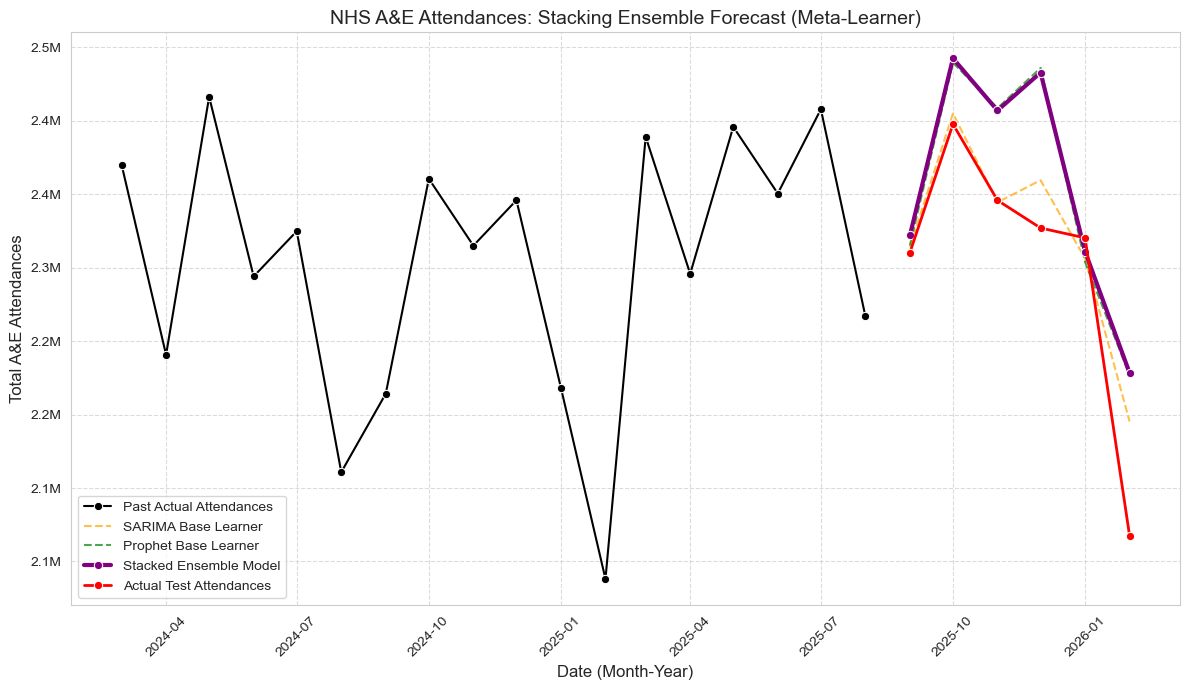

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
import statsmodels.api as sm
from prophet import Prophet
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore")

# =========================================================
# PREPARATION: Split Data into Train/Test (Last 6 Months)
# =========================================================
data = yearlyDataUk.copy()

# 6-Month Test Set Split
train_data = data.iloc[:-6].sort_values(by='ds').reset_index(drop=True)
test_data = data.iloc[-6:].sort_values(by='ds').reset_index(drop=True)
cutoff_date = train_data['ds'].max()

# =========================================================
# STAGE 1A: PROPHET FORECASTING
# =========================================================
print("--- Training Prophet Model ---")
model_prophet = Prophet(interval_width=0.95, changepoint_prior_scale=0.05, seasonality_prior_scale=10.0, seasonality_mode='additive')
model_prophet.add_seasonality(name='monthly', period=30.5, fourier_order=5)
model_prophet.fit(train_data)

# Prophet In-Sample (Train) Predictions for the Meta-Learner
prophet_train_preds = model_prophet.predict(train_data)[['ds', 'yhat']].rename(columns={'yhat': 'Prophet_Pred'})

# Prophet Out-of-Sample (Test) Predictions
future_dates = model_prophet.make_future_dataframe(periods=len(test_data), freq='MS')
prophet_test_preds = model_prophet.predict(future_dates)
prophet_test_preds = prophet_test_preds[prophet_test_preds['ds'] > cutoff_date][['ds', 'yhat']].rename(columns={'yhat': 'Prophet_Pred'}).reset_index(drop=True)

# =========================================================
# STAGE 1B: SARIMA FORECASTING
# =========================================================
print("--- Training SARIMA Model ---")
trainseries = train_data.set_index('ds')['y'].asfreq('MS')

model_sarima = sm.tsa.statespace.SARIMAX(trainseries, order=(1, 2, 1), seasonal_order=(1, 1, 1, 12), enforce_stationarity=False, enforce_invertibility=False)
model_sarima_fit = model_sarima.fit(disp=False)

# SARIMA In-Sample (Train) Predictions for the Meta-Learner
# We start from index 13 to avoid the initial NaN values caused by the 12-month seasonal differencing
sarima_train_preds = pd.DataFrame({
    'ds': train_data['ds'].iloc[13:].values,
    'SARIMA_Pred': model_sarima_fit.fittedvalues.iloc[13:].values
})

# SARIMA Out-of-Sample (Test) Predictions
forecast_res = model_sarima_fit.get_forecast(steps=len(test_data))
sarima_test_preds = pd.DataFrame({'ds': test_data['ds'].values, 'SARIMA_Pred': forecast_res.predicted_mean.values})

# =========================================================
# STAGE 1C: STACKING ENSEMBLE (Meta-Learner)
# =========================================================
print("--- Training Stacking Ensemble (Meta-Learner) ---")

# 1. Prepare Meta-Training Data
# Merge Prophet Train Preds, SARIMA Train Preds, and Actual y
meta_train_df = pd.merge(prophet_train_preds, sarima_train_preds, on='ds', how='inner')
meta_train_df = pd.merge(meta_train_df, train_data, on='ds', how='inner')

# Features (X) are the predictions of the base models. Target (y) is the actual attendances.
X_meta_train = meta_train_df[['Prophet_Pred', 'SARIMA_Pred']]
y_meta_train = meta_train_df['y']

# 2. Train the Meta-Learner (Linear Regression)
meta_learner = LinearRegression()
meta_learner.fit(X_meta_train, y_meta_train)

# Print the learned weights (Coefficients)
print(f"Meta-Learner Weights -> Prophet: {meta_learner.coef_[0]:.4f}, SARIMA: {meta_learner.coef_[1]:.4f}")

# 3. Predict the Test Set using the Meta-Learner
# Merge Prophet Test Preds and SARIMA Test Preds
df_hybrid_test = pd.merge(prophet_test_preds, sarima_test_preds, on='ds', how='inner')
X_meta_test = df_hybrid_test[['Prophet_Pred', 'SARIMA_Pred']]

# Generate final Stacking Ensemble prediction
df_hybrid_test['Stacked_Attendances'] = meta_learner.predict(X_meta_test).round(0).astype(int)

# =========================================================
# VISUALIZATION
# =========================================================
plt.figure(figsize=(12, 7))

# Plot Past Actuals
sns.lineplot(x='ds', y='y', data=train_data.tail(18), label='Past Actual Attendances', marker='o', color='black')

# Plot Base Models (Dashed)
sns.lineplot(x='ds', y='SARIMA_Pred', data=df_hybrid_test, label='SARIMA Base Learner', linestyle='--', color='orange', alpha=0.7)
sns.lineplot(x='ds', y='Prophet_Pred', data=df_hybrid_test, label='Prophet Base Learner', linestyle='--', color='green', alpha=0.7)

# Plot Stacking Ensemble (Solid)
sns.lineplot(x='ds', y='Stacked_Attendances', data=df_hybrid_test, label='Stacked Ensemble Model', marker='o', color='purple', linewidth=3)

# Plot Actual Test Data
sns.lineplot(x='ds', y='y', data=test_data, label='Actual Test Attendances', marker='o', color='red', linewidth=2)

plt.title('NHS A&E Attendances: Stacking Ensemble Forecast (Meta-Learner)', fontsize=14)
plt.xlabel('Date (Month-Year)', fontsize=12)
plt.ylabel('Total A&E Attendances', fontsize=12)
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1000000:.1f}M'))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

--- Training Prophet Model ---


10:40:35 - cmdstanpy - INFO - Chain [1] start processing
10:40:36 - cmdstanpy - INFO - Chain [1] done processing


--- Training SARIMA Model ---
--- Training Stacking Ensemble (Meta-Learner) ---
Meta-Learner Weights -> Prophet: 0.8636, SARIMA: 0.1449

--- MODEL EVALUATION: ATTENDANCES (4-Month Holdout) ---

[Prophet Base Learner]
MAE  : 57,386 attendances
MSE  : 4,968,001,224
RMSE : 70,484 attendances
MAPE : 2.53%

[SARIMA Base Learner]
MAE  : 22,846 attendances
MSE  : 1,230,505,410
RMSE : 35,079 attendances
MAPE : 1.04%

[Stacking Ensemble Model]
MAE  : 57,280 attendances
MSE  : 4,910,487,453
RMSE : 70,075 attendances
MAPE : 2.53%


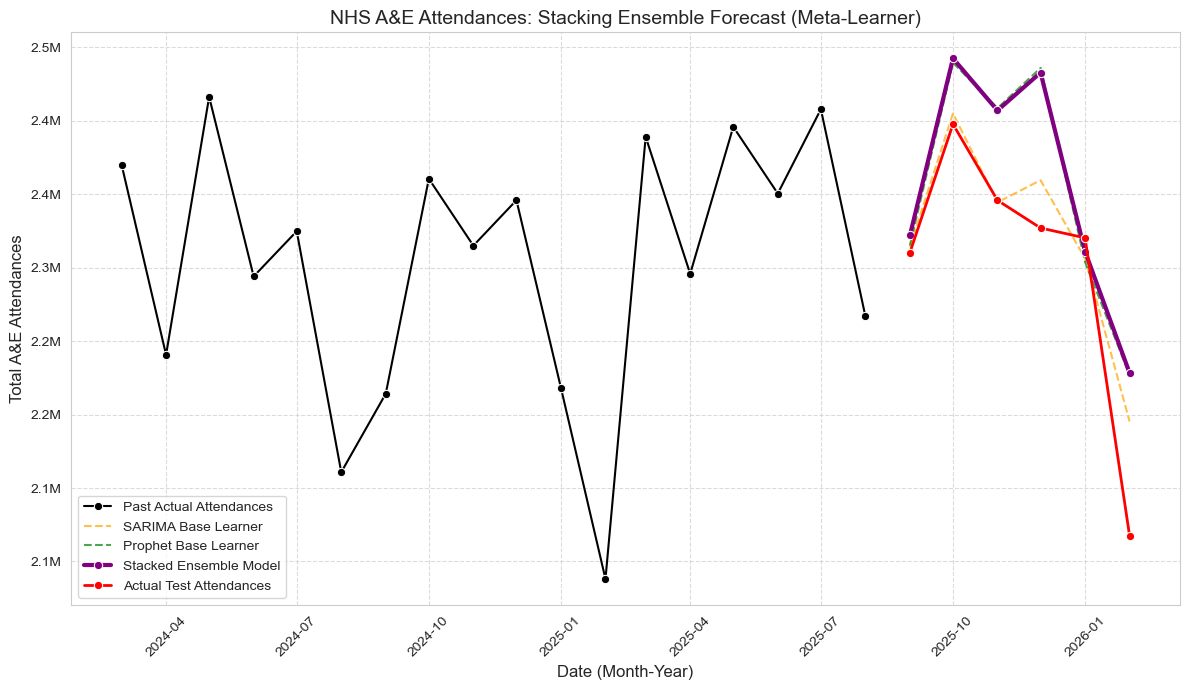

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
import statsmodels.api as sm
from prophet import Prophet
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore")

# =========================================================
# PREPARATION: Split Data into Train/Test (Last 6 Months)
# =========================================================
data = yearlyDataUk.copy()

# 6-Month Test Set Split
train_data = data.iloc[:-6].sort_values(by='ds').reset_index(drop=True)
test_data = data.iloc[-6:].sort_values(by='ds').reset_index(drop=True)
cutoff_date = train_data['ds'].max()

# =========================================================
# STAGE 1A: PROPHET FORECASTING
# =========================================================
print("--- Training Prophet Model ---")
model_prophet = Prophet(interval_width=0.95, changepoint_prior_scale=0.05, seasonality_prior_scale=10.0, seasonality_mode='additive')
model_prophet.add_seasonality(name='monthly', period=30.5, fourier_order=5)
model_prophet.fit(train_data)

# Prophet In-Sample (Train) Predictions for the Meta-Learner
prophet_train_preds = model_prophet.predict(train_data)[['ds', 'yhat']].rename(columns={'yhat': 'Prophet_Pred'})

# Prophet Out-of-Sample (Test) Predictions
future_dates = model_prophet.make_future_dataframe(periods=len(test_data), freq='MS')
prophet_test_preds = model_prophet.predict(future_dates)
prophet_test_preds = prophet_test_preds[prophet_test_preds['ds'] > cutoff_date][['ds', 'yhat']].rename(columns={'yhat': 'Prophet_Pred'}).reset_index(drop=True)

# =========================================================
# STAGE 1B: SARIMA FORECASTING
# =========================================================
print("--- Training SARIMA Model ---")
trainseries = train_data.set_index('ds')['y'].asfreq('MS')

model_sarima = sm.tsa.statespace.SARIMAX(trainseries, order=(1, 2, 1), seasonal_order=(1, 1, 1, 12), enforce_stationarity=False, enforce_invertibility=False)
model_sarima_fit = model_sarima.fit(disp=False)

# SARIMA In-Sample (Train) Predictions for the Meta-Learner
# We start from index 13 to avoid the initial NaN values caused by the 12-month seasonal differencing
sarima_train_preds = pd.DataFrame({
    'ds': train_data['ds'].iloc[13:].values,
    'SARIMA_Pred': model_sarima_fit.fittedvalues.iloc[13:].values
})

# SARIMA Out-of-Sample (Test) Predictions
forecast_res = model_sarima_fit.get_forecast(steps=len(test_data))
sarima_test_preds = pd.DataFrame({'ds': test_data['ds'].values, 'SARIMA_Pred': forecast_res.predicted_mean.values})

# =========================================================
# STAGE 1C: STACKING ENSEMBLE (Meta-Learner)
# =========================================================
print("--- Training Stacking Ensemble (Meta-Learner) ---")

# 1. Prepare Meta-Training Data
# Merge Prophet Train Preds, SARIMA Train Preds, and Actual y
meta_train_df = pd.merge(prophet_train_preds, sarima_train_preds, on='ds', how='inner')
meta_train_df = pd.merge(meta_train_df, train_data, on='ds', how='inner')

# Features (X) are the predictions of the base models. Target (y) is the actual attendances.
X_meta_train = meta_train_df[['Prophet_Pred', 'SARIMA_Pred']]
y_meta_train = meta_train_df['y']

# 2. Train the Meta-Learner (Linear Regression)
meta_learner = LinearRegression()
meta_learner.fit(X_meta_train, y_meta_train)

# Print the learned weights (Coefficients)
print(f"Meta-Learner Weights -> Prophet: {meta_learner.coef_[0]:.4f}, SARIMA: {meta_learner.coef_[1]:.4f}")

# 3. Predict the Test Set using the Meta-Learner
# Merge Prophet Test Preds and SARIMA Test Preds
df_hybrid_test = pd.merge(prophet_test_preds, sarima_test_preds, on='ds', how='inner')
X_meta_test = df_hybrid_test[['Prophet_Pred', 'SARIMA_Pred']]

# Generate final Stacking Ensemble prediction
df_hybrid_test['Stacked_Attendances'] = meta_learner.predict(X_meta_test).round(0).astype(int)

# =========================================================
# STAGE 1D: EVALUATION METRICS (All Models)
# =========================================================
print("\n--- MODEL EVALUATION: ATTENDANCES (4-Month Holdout) ---")

# The actual true values from the test set
y_true_attendances = test_data['y'].values

# The predicted values
y_pred_prophet = df_hybrid_test['Prophet_Pred'].values
y_pred_sarima = df_hybrid_test['SARIMA_Pred'].values
y_pred_stacked = df_hybrid_test['Stacked_Attendances'].values

# Helper function to calculate and print metrics
def print_metrics(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f"\n[{model_name}]")
    print(f"MAE  : {mae:,.0f} attendances")
    print(f"MSE  : {mse:,.0f}")
    print(f"RMSE : {rmse:,.0f} attendances")
    print(f"MAPE : {mape:.2f}%")

print_metrics("Prophet Base Learner", y_true_attendances, y_pred_prophet)
print_metrics("SARIMA Base Learner", y_true_attendances, y_pred_sarima)
print_metrics("Stacking Ensemble Model", y_true_attendances, y_pred_stacked)

# =========================================================
# VISUALIZATION
# =========================================================
plt.figure(figsize=(12, 7))

# Plot Past Actuals
sns.lineplot(x='ds', y='y', data=train_data.tail(18), label='Past Actual Attendances', marker='o', color='black')

# Plot Base Models (Dashed)
sns.lineplot(x='ds', y='SARIMA_Pred', data=df_hybrid_test, label='SARIMA Base Learner', linestyle='--', color='orange', alpha=0.7)
sns.lineplot(x='ds', y='Prophet_Pred', data=df_hybrid_test, label='Prophet Base Learner', linestyle='--', color='green', alpha=0.7)

# Plot Stacking Ensemble (Solid)
sns.lineplot(x='ds', y='Stacked_Attendances', data=df_hybrid_test, label='Stacked Ensemble Model', marker='o', color='purple', linewidth=3)

# Plot Actual Test Data
sns.lineplot(x='ds', y='y', data=test_data, label='Actual Test Attendances', marker='o', color='red', linewidth=2)

plt.title('NHS A&E Attendances: Stacking Ensemble Forecast (Meta-Learner)', fontsize=14)
plt.xlabel('Date (Month-Year)', fontsize=12)
plt.ylabel('Total A&E Attendances', fontsize=12)
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1000000:.1f}M'))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()